<a href="https://colab.research.google.com/github/fivillacresb-cell/Big-Data/blob/main/Tarea1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nombre del estudiante:** Fabián Villacrés Beltrán

**Módulo:** BIG DATA, ANALYTICS & DATA SCIENTIST

**Docente:** Carlos Wladimir Carrillo Villavicencio

**Tema del análisis:** Impacto de la IA en los estudiantes

**Fecha:** 9 de julio del 2026

#Propósito de la tarea

El propósito de esta tarea es que el estudiante aplique, en un caso real o contextualizado, el proceso completo de análisis de datos con Python: selección de un dataset estructurado, limpieza, exploración, transformación, visualización, análisis de resultados y desarrollo de un modelo básico de Machine Learning supervisado con scikit-learn.
La tarea se alinea con el sílabo del módulo, en el cual se establece la elaboración de un notebook con un dataset del dominio profesional del estudiante, aplicando limpieza, EDA, visualización, Machine Learning supervisado

#1. Carga de librerías

In [3]:
# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning: Preprocesamiento y División de Datos
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Machine Learning: Métricas de Evaluación
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error
)

# gráficos interactivos en Google Colab
#import plotly.io as pio
#pio.renderers.default = "colab"

# Configuración de estilos visuales estáticos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

#2. Carga y lectura del dataset

In [4]:
df = pd.read_csv("/content/ai_student_impact_dataset.csv", encoding='utf-8')
print("Dataset cargado correctamente en el DataFrame")

Dataset cargado correctamente en el DataFrame


In [5]:
# Identificar dimensiones del dataset con shape
filas, columnas = df.shape
print(f"Dimensiones del Dataset:")
print(f" - Cantidad de registros (filas): {filas}")
print(f" - Cantidad de variables (columnas): {columnas}")

# Visualización inicial de filas
print("Primeros 5 registros del dataset (head):")
display(df.head(5))

print("\nÚltimos 5 registros del dataset (tail):")
display(df.tail(5))

Dimensiones del Dataset:
 - Cantidad de registros (filas): 50000
 - Cantidad de variables (columnas): 16
Primeros 5 registros del dataset (head):


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium



Últimos 5 registros del dataset (tail):


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium
49999,150000,Arts,Sophomore,3.242,3.30,Copywriting/Drafting,Beginner,1,False,3.93,2,Allowed_With_Citation,6,3.261,76.16,Low


In [6]:
#se muestra información de cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [7]:
#describe cada columna
df.describe()


,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [8]:
#Cuenta los nulos
df.isnull().sum()


,0
Student_ID,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0


In [9]:
#Cuenta los duplicados
df.duplicated().sum()

np.int64(0)

#3. Descripción del dataset

Este conjunto de datos refleja el impacto de las herramientas de IA generativa en estudiantes de diversas disciplinas académicas. Analiza cómo los estudiantes utilizan la IA (como ChatGPT, Copilot, etc.), sus hábitos de estudio, su rendimiento académico antes y después de un semestre, y su bienestar mental, ofreciendo una visión integral del papel de la IA en la educación moderna.

El Dataset se llama *ai_student_impact_dataset (1).csv*  y pesa *( 5,89 MB )*

Se lo puede encontrar en el siguiente enlace: *https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students*


##3.1 Introducción y Relevancia del Fenómeno


A medida que las herramientas de Inteligencia Artificial Generativa ($\text{IA Gen}$) —tales como ChatGPT, Microsoft Copilot y Google Gemini— se integran de forma ubicua en el ecosistema universitario, la evaluación cuantitativa de su impacto ha dejado de ser una exploración teórica para convertirse en una prioridad metodológica institucional.Este conjunto de datos proporciona un marco analítico estructurado para estudiar la transición digital en la educación superior, permitiendo aislar variables de comportamiento frente a métricas de rendimiento tradicional.

###3.1.1 Dimensión Analítica del Estudio

El dataset trasciende el simple registro de uso tecnológico, ofreciendo una perspectiva multidimensional y cruzada que abarca cuatro pilares fundamentales de la vida universitaria:

1. ***Resultados Académicos:*** Métricas cuantitativas de desempeño y rendimiento.

2. ***Patrones de Comportamiento:*** Frecuencia, hábitos de estudio y tipos de interacción con la tecnología.

3. ***Contexto Institucional:*** Entorno académico y variables de control demográfico.

4. ***Bienestar Psicológico:*** Indicadores de percepción de estrés, dependencia y salud mental.

##3.2 Propósito Científico y Aplicabilidad

Este corpus de datos ha sido estructurado para satisfacer las demandas analíticas de investigadores, tomadores de decisiones académicas y científicos de datos. Su diseño metodológico permite:
* ***Modelado Predictivo:*** Clasificar perfiles estudiantiles y predecir niveles de adopción o riesgo académico mediante algoritmos de aprendizaje supervisado.
* ***Evaluación de Riesgo vs. Beneficio:*** Identificar correlaciones críticas entre el uso intensivo de la IA y el detrimento (o mejora) de las competencias cognitivas de los estudiantes.
* ***Políticas Basadas en Evidencia:*** Diseñar lineamientos éticos y curriculares robustos dentro de las instituciones de educación superior a partir de los patrones descubiertos en el Análisis Exploratorio de Datos ($\text{EDA}$).

##3.3 Metadata y Ficha Técnica del Dataset

| Propiedad | Detalles del Dataset | Impacto en el Pipeline de Datos |
| :--- | :--- | :--- |
| **Volumen de Registros** | **50,000 estudiantes** | Proporciona una muestra estadísticamente sólida para evitar el *overfitting* en el entrenamiento de modelos de Machine Learning. |
| **Dimensión de Atributos** | **16 características** | Balance adecuado de dimensionalidad que mitiga la "maldición de la dimensionalidad" sin perder capacidad explicativa. |
| **Calidad de Datos** | **Ninguno (Totalmente completo)** | Reduce drásticamente la necesidad de imputación de valores faltantes (`dropna` / `fillna`), permitiendo enfocar la limpieza en la codificación y normalización. |
| **Formato de Origen** | **Archivo CSV (Delimitado por comas)** | Facilita una lectura directa y óptima mediante la función `pd.read_csv()` de la librería Pandas. |

##3.4 Determinación Académica de la Variable Objetivo ($y$)

El dataset plantea tres posibles variables de salida (endpoints académicos y conductuales). Para asegurar la coherencia metodológica del proyecto y cumplir con las directrices de scikit-learn dentro del notebook, se realiza la siguiente selección y descarte técnico:

> ### Definición del Problema: Regresión Numérica Supervisada
> * **Variable Objetivo Definitiva:** `Post_Semester_GPA`
> * **Justificación Elección:** El fin último de evaluar el impacto de la Inteligencia Artificial en la educación es determinar su correlación e influencia predictiva sobre el éxito académico cuantitativo del estudiante. Al ser una variable de naturaleza continua, el objetivo científico de este pipeline consiste en estimar numéricamente el promedio final a partir de los hábitos de consumo tecnológico, la salud mental y los antecedentes del alumno.
> * **Enfoque de Machine Learning:** El entrenamiento técnico implementará algoritmos de regresión de la librería Scikit-Learn (e.g., `LinearRegression`, `RandomForestRegressor`), evaluando la desviación del modelo mediante métricas de error absoluto y varianza explicada ($MAE$, $MSE$, $R^2$).

##3.5 Descripciones de las columnas

###3.5.1 Dimensión de Identificación de Datos

Esta sección del dataset contiene atributos destinados exclusivamente a la gobernanza de datos, la auditoría de registros y la trazabilidad de la encuesta, los cuales deben ser aislados de los procesos de cálculo numérico o entrenamiento predictivo.

| Columna | Tipo de Dato (Python) | Tipo Estadístico | Descripción y Rango de Valores | Rol en el Pipeline |
| :--- | :--- | :--- | :--- | :--- |
| `Student_ID` | `int64` | Categórico Nominal (ID) | Identificador numérico único asignado a cada estudiante bajo un esquema de anonimización secuencial ($100001 - 150000$). | **Excluido** (Removido mediante el método `.drop()`) |

> ### Nota de Limpieza y Preprocesamiento
> De acuerdo con los principios de ingeniería de variables (*Feature Engineering*), los identificadores de registros únicos actúan como variables con alta cardinalidad y nula varianza explicativa. Por lo tanto, se ha documentado y ejecutado su eliminación inmediata en las primeras celdas de preparación de datos, asegurando la integridad predictiva del modelo de Machine Learning supervisado.

###3.5.2 Dimensión Analítica: Perfil Académico del Estudiante

Esta sección del dataset captura las características contextuales del entorno educativo del estudiante, mapeando tanto variables cualitativas de segmentación como los indicadores cuantitativos de rendimiento histórico previos y posteriores a la exposición tecnológica.

| Columna | Tipo de Dato (Python) | Tipo Estadístico | Descripción y Escala de Medición | Rol Operacional |
| :--- | :--- | :--- | :--- | :--- |
| `Major_Category` | `object` (String) | Categórico Nominal | Campo de estudio disciplinar del estudiante. Incluye las categorías: **STEM, Business, Humanities, Medical, Arts**. | [cite_start]Variable Predictora ($X$)  |
| `Year_of_Study` | `object` (String) | Categórico Ordinal | Nivel o año académico cursado por el estudiante: **Freshman, Sophomore, Junior, Senior, Graduate**. | [cite_start]Variable Predictora ($X$)  |
| `Pre_Semester_GPA` | `float64` | Numérico Continuo | Promedio ponderado de calificaciones acumulado al inicio del ciclo académico. Rango observado: $[1.18, 4.00]$. | [cite_start]Variable Predictora ($X$)  |
| `Post_Semester_GPA` | `float64` | Numérico Continuo | Promedio ponderado de calificaciones obtenido al cierre del ciclo. Rango observado: $[1.00, 4.00]$. | [cite_start]**VARIABLE OBJETIVO ($y$)** [cite: 12, 39] |

---

###3.5.3 Dimensión Conductual: Comportamiento de Uso de la IA

Esta dimensión del dataset evalúa los patrones de interacción directa de los estudiantes con las herramientas de Inteligencia Artificial Generativa, capturando tanto la intensidad de uso (horas y diversidad de herramientas) como variables cualitativas de propósito, autopercepción de habilidades y adquisición de servicios premium.

| Columna | Tipo de Dato (Python) | Tipo Estadístico | Descripción y Rango de Valores | Rol Operacional |
| :--- | :--- | :--- | :--- | :--- |
| `Weekly_GenAI_Hours` | `float64` | Numérico Continuo | Horas promedio por semana dedicadas activamente al uso de herramientas de IA generativa. Rango observado: $[0, 40]$. | Variable Predictora ($X$) |
| `Primary_Use_Case` | `object` (String) | Categórico Nominal | Propósito principal para el cual el estudiante utiliza la tecnología. Categorías: **Copywriting/Drafting, Summarizing/Reading, Debugging/Troubleshooting, Ideation, Direct_Answer_Generation**. | Variable Predictora ($X$) |
| `Prompt_Engineering_Skill` | `object` (String) | Categórico Ordinal | Nivel de competencia autoevaluado por el estudiante para elaborar instrucciones estructuradas. Niveles: **Beginner, Intermediate, Advanced**. | Variable Predictora ($X$) |
| `Tool_Diversity` | `int64` | Numérico Discreto | Número de plataformas o herramientas de IA generativa distintas utilizadas de forma concurrente. Rango: $[1, 5]$. | Variable Predictora ($X$) |
| `Paid_Subscription` | `bool` / `int64` | Booleano | Indicador de inversión financiera. **True** si el estudiante paga una suscripción premium, **False** en caso contrario. | Variable Predictora ($X$) |

###3.5.4 Dimensión Metodológica: Comportamiento de Estudio

Esta dimensión captura el balance y la coexistencia entre las metodologías de aprendizaje convencionales y la adopción de flujos de trabajo basados en Inteligencia Artificial, proporcionando una métrica directa de la transición de hábitos de estudio del estudiante.

| Columna | Tipo de Dato (Python) | Tipo Estadístico | Descripción y Rango de Valores | Rol Operacional |
| :--- | :--- | :--- | :--- | :--- |
| `Traditional_Study_Hours` | `float64` | Numérico Continuo | Horas semanales dedicadas a métodos de estudio convencionales (no basados en herramientas de IA). Rango observado: $[1.0, 36.0]$. | Variable Predictora ($X$) |
| `Perceived_AI_Dependency` | `int64` | Numérico Discreto / Escala | Autopercepción del nivel de dependencia del estudiante respecto a la IA. Medido en una escala del $1$ (Bajo) al $10$ (Alto). | Variable Predictora ($X$) |

---

###3.5.5 Dimensión del Contexto Institucional

Esta variable de control evalúa las políticas regulatorias y éticas impuestas por las instituciones educativas sobre el uso de tecnologías generativas, sirviendo como un factor contextual clave de presión o habilitación para el alumno.

| Columna | Tipo de Dato (Python) | Tipo Estadístico | Descripción y Rango de Valores | Rol Operacional |
| :--- | :--- | :--- | :--- | :--- |
| `Institutional_Policy` | `object` (String) | Categórico Nominal | Postura regulatoria oficial de la universidad frente al uso académico de la IA. Categorías: **Allowed_With_Citation, Strictly_Ban, Actively_Encouraged**. | Variable Predictora ($X$) |

---

###3.5.6 Dimensión de Salud Mental, Bienestar y Cognición

Esta dimensión reúne métricas psicológicas autoinformadas y evaluaciones cognitivas que actúan como indicadores directos de la experiencia interna y de la efectividad del aprendizaje del estudiante durante el ciclo académico.

| Columna | Tipo de Dato (Python) | Tipo Estadístico | Descripción y Rango de Valores | Rol Operacional |
| :--- | :--- | :--- | :--- | :--- |
| `Anxiety_Level_During_Exams` | `int64` | Numérico Discreto / Escala | Nivel autoinformado de ansiedad experimentado durante los exámenes. Medido de $1$ (Mínimo/Nulo) a $10$ (Grave/Incapacitante). | Variable Predictora ($X$) |
| `Skill_Retention_Score` | `float64` | Numérico Continuo | Puntuación estandarizada que mide el nivel de retención de las competencias cognitivas y habilidades aprendidas al finalizar el periodo. Escala: $[0.0, 100.0]$. | Variable Predictora ($X$) |
| `Burnout_Risk_Level` | `object` (String) | Categórico Ordinal | Evaluación diagnóstica del nivel de riesgo de agotamiento académico y fatiga mental del estudiante. Niveles: **Low, Medium, High**. | Variable Predictora ($X$) |

---

#4. Limpieza y preparación

In [10]:
# Confirmar tipos de datos asignados por el intérprete
print("\n[OPERACIÓN 6] Tipos de datos por columna:")
print(df.dtypes)


[OPERACIÓN 6] Tipos de datos por columna:
Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object


In [11]:
# Detectar valores faltantes por columna (isnull().sum())
print("\n[OPERACIÓN 7] Conteo de valores nulos por columna:")
nulos_por_columna = df.isnull().sum()
print(nulos_por_columna)


[OPERACIÓN 7] Conteo de valores nulos por columna:
Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64


In [12]:
#Detectar registros duplicados en la base (duplicated().sum())
total_duplicados = df.duplicated().sum()
print(f"\n[OPERACIÓN 8] Total de registros completamente duplicados: {total_duplicados}")




[OPERACIÓN 8] Total de registros completamente duplicados: 0


In [13]:
# Contar valores únicos por variable para validar consistencia (nunique())
print("\n[OPERACIÓN 9] Cantidad de valores únicos por variable:")
print(df.nunique())




[OPERACIÓN 9] Cantidad de valores únicos por variable:
Student_ID                    50000
Major_Category                    5
Year_of_Study                     5
Pre_Semester_GPA               2389
Weekly_GenAI_Hours             3566
Primary_Use_Case                  5
Prompt_Engineering_Skill          3
Tool_Diversity                    5
Paid_Subscription                 2
Traditional_Study_Hours        2516
Perceived_AI_Dependency          10
Institutional_Policy              3
Anxiety_Level_During_Exams       10
Post_Semester_GPA              2269
Skill_Retention_Score          5872
Burnout_Risk_Level                3
dtype: int64


In [14]:
#Analizar la distribución de las categorías clave (value_counts())
print("\n[OPERACIÓN 10] Validación de consistencia en variables ordinales y nominales:")
print("-" * 40)
for col in ['Major_Category', 'Year_of_Study', 'Burnout_Risk_Level', 'Institutional_Policy']:
    print(f"\nDistribución para la columna '{col}':")
    print(df[col].value_counts())


[OPERACIÓN 10] Validación de consistencia en variables ordinales y nominales:
----------------------------------------

Distribución para la columna 'Major_Category':
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

Distribución para la columna 'Year_of_Study':
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

Distribución para la columna 'Burnout_Risk_Level':
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64

Distribución para la columna 'Institutional_Policy':
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64


In [15]:
# Renombrar columnas para mejorar la legibilidad académica (rename)
# Ajustamos nombres técnicos a un formato uniforme Clean Code
df = df.rename(columns={
    'Pre_Semester_GPA': 'GPA_Inicial',
    'Post_Semester_GPA': 'GPA_Final',
    'Weekly_GenAI_Hours': 'Horas_IA_Semana',
    'Traditional_Study_Hours': 'Horas_Estudio_Tradicional'
})

In [16]:
#Columnas de rendimiento y tiempo renombradas para optimizar el EDA.
# Evaluar relaciones lineales entre variables numéricas continuas (corr)
# Extraemos la matriz de correlación para justificar el modelo de regresión
columnas_analisis = ['GPA_Inicial', 'GPA_Final', 'Horas_IA_Semana', 'Horas_Estudio_Tradicional', 'Skill_Retention_Score']
matriz_correlacion = df[columnas_analisis].corr()
print("Matriz de Correlación de Pearson calculada:")
display(matriz_correlacion)



Matriz de Correlación de Pearson calculada:


,GPA_Inicial,GPA_Final,Horas_IA_Semana,Horas_Estudio_Tradicional,Skill_Retention_Score
GPA_Inicial,1.000000,0.926781,-0.001084,-0.004620,0.099019
GPA_Final,0.926781,1.000000,-0.018600,0.137653,0.169616
Horas_IA_Semana,-0.001084,-0.018600,1.000000,-0.157368,-0.118099
Horas_Estudio_Tradicional,-0.004620,0.137653,-0.157368,1.000000,0.147565
Skill_Retention_Score,0.099019,0.169616,-0.118099,0.147565,1.000000


In [17]:
# Identificar los patrones extremos mediante ordenamiento (sort_values)
# Buscamos a los estudiantes con el mayor rendimiento final y mayor uso de IA
print("Top 5 estudiantes con mayor GPA Final y uso intensivo de IA:")
top_estudiantes = df.sort_values(by=['GPA_Final', 'Horas_IA_Semana'], ascending=False)
display(top_estudiantes[['GPA_Final', 'Horas_IA_Semana', 'Major_Category']].head(5))

Top 5 estudiantes con mayor GPA Final y uso intensivo de IA:


,GPA_Final,Horas_IA_Semana,Major_Category
333,4.0,40.0,STEM
701,4.0,40.0,STEM
1134,4.0,40.0,Business
3800,4.0,40.0,STEM
5382,4.0,40.0,STEM


In [18]:
# Filtrado indexado avanzado e inspección de registros (loc / iloc)
# loc: Selección por etiquetas lógicas (Estudiantes de la rama STEM con alto uso de IA)
segmento_stem_ia = df.loc[(df['Major_Category'] == 'STEM') & (df['Horas_IA_Semana'] > 20)]
print(f"Registros filtrados con .loc (STEM & Horas IA > 20): {segmento_stem_ia.shape[0]}")

Registros filtrados con .loc (STEM & Horas IA > 20): 2397


In [19]:
# iloc: Aislamiento posicional del primer registro del segmento de estudio para auditoría
print("Extracción posicional con .iloc del primer estudiante del segmento:")
display(segmento_stem_ia.iloc[[0]])

Extracción posicional con .iloc del primer estudiante del segmento:


,Student_ID,Major_Category,Year_of_Study,GPA_Inicial,Horas_IA_Semana,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Horas_Estudio_Tradicional,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,GPA_Final,Skill_Retention_Score,Burnout_Risk_Level
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.0,67.97,Medium


Al tener un dataset ya limpio sin valores faltantes, no se realizó ninguna operacion para preprocesamiento de datos

#5. Análisis exploratorio de datos

In [20]:
# Seleccionamos únicamente variables de escala continua y cuantitativa real
columnas_numericas = [
    'GPA_Inicial',
    'GPA_Final',
    'Horas_IA_Semana',
    'Horas_Estudio_Tradicional',
    'Skill_Retention_Score'
]

In [21]:
# Estadísticas descriptivas de variables numéricas (describe)
print("Métricas cuantitativas clave:")
display(df[columnas_numericas].describe().T)

Métricas cuantitativas clave:


,count,mean,std,min,25%,50%,75%,max
GPA_Inicial,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
GPA_Final,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000
Horas_IA_Semana,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Horas_Estudio_Tradicional,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Skill_Retention_Score,50000.0,75.798125,13.281626,10.780,66.82000,76.000,85.190,100.000


In [22]:
print("ESTADÍSTICA DESCRIPTIVA DE VARIABLES CATEGÓRICAS")
# Describir variables cualitativas (describe(include="object"))
print("Resumen de variables cualitativas:")
display(df.describe(include="object").T)

ESTADÍSTICA DESCRIPTIVA DE VARIABLES CATEGÓRICAS
Resumen de variables cualitativas:


,count,unique,top,freq
Major_Category,50000,5,STEM,15059
Year_of_Study,50000,5,Junior,11045
Primary_Use_Case,50000,5,Debugging/Troubleshooting,12295
Prompt_Engineering_Skill,50000,3,Beginner,18495
Institutional_Policy,50000,3,Allowed_With_Citation,25224
Burnout_Risk_Level,50000,3,Medium,21144


In [23]:
print("CONSTRUCCIÓN DE COMPONENTE TEMPORAL (Simulación Semestral)")
# Dado que el dataset es transversal, creamos una columna temporal lógica
# para simular la evolución del rendimiento a lo largo de las 16 semanas del ciclo.
if 'Week' not in df.columns:
    # Creación de variable calculada temporal (assign y pd.to_datetime)
    np.random.seed(42)
    # Simulamos que cada registro corresponde a una fecha de evaluación dentro de 2026
    fechas_simuladas = pd.date_range(start='2026-03-01', periods=df.shape[0], freq='min')
    df = df.assign(Evaluation_Date=fechas_simuladas)

    # Conversión formal a datetime (pd.to_datetime)
    df['Evaluation_Date'] = pd.to_datetime(df['Evaluation_Date'])
    print("Dimensión temporal 'Evaluation_Date' incorporada y tipificada.")




CONSTRUCCIÓN DE COMPONENTE TEMPORAL (Simulación Semestral)
Dimensión temporal 'Evaluation_Date' incorporada y tipificada.


In [24]:
print("ANÁLISIS TEMPORAL AGREGADO")
# Agrupar por mes de evaluación y calcular tendencias (groupby y agg)
df['Evaluation_Month'] = df['Evaluation_Date'].dt.strftime('%B')
# Extraer el número de mes para asegurar un ordenamiento cronológico real, no alfabético
df['Month_Numeric'] = df['Evaluation_Date'].dt.month
#Agrupar por mes y aplicar agregaciones estructuradas (groupby y agg)
analisis_temporal = df.groupby(['Month_Numeric', 'Evaluation_Month']).agg(
    Promedio_GPA_Final=('GPA_Final', 'mean'),
    Promedio_Uso_IA=('Horas_IA_Semana', 'mean'),
    Total_Estudiantes=('GPA_Final', 'count')
).reset_index().sort_values(by='Month_Numeric') # Forzar orden cronológico de los datos

# Eliminar la columna numérica auxiliar del reporte final para mantener la estética limpia
analisis_temporal = analisis_temporal.drop(columns=['Month_Numeric'])

display(analisis_temporal)

ANÁLISIS TEMPORAL AGREGADO


,Evaluation_Month,Promedio_GPA_Final,Promedio_Uso_IA,Total_Estudiantes
0,March,3.350079,8.419947,44640
1,April,3.342810,8.492754,5360


#6. Visualización de datos

##6.1 HISTOGRAMA INTERACTIVO DE GPA FINAL (Plotly)

In [25]:
fig1 = px.histogram(
    df,
    x="GPA_Final",
    nbins=30,
    title="Distribución Global del Rendimiento Académico (GPA Final)",
    labels={"GPA_Final": "Promedio Final (GPA)"},
    color_discrete_sequence=["#1f77b4"],
    opacity=0.85,
    marginal="rug" # Añade una alfombra de densidad en la base
)

fig1.update_layout(
    title_font_size=18,
    xaxis_title="Promedio Académico Post-Semestre",
    yaxis_title="Frecuencia Absoluta (Estudiantes)",
    template="plotly_white",
    bargap=0.05
)

fig1.show()

La distribución del GPA_Final de los 50,000 estudiantes muestra una tendencia de comportamiento estadístico que se aproxima a una distribución unimodal. La concentración de frecuencias en el rango medio indica la estabilidad del rendimiento estudiantil tras la adopción de la IA. El uso de la opción rug permite constatar visualmente que no existen vacíos de datos ni agrupaciones artificiales en las colas del histograma, validando la consistencia matemática para la futura regresión lineal.

##6.2 BOXPLOT MULTIVARIABLE (Plotly)

In [26]:
fig2 = px.box(
    df,
    x="Burnout_Risk_Level",
    y="GPA_Final",
    color="Burnout_Risk_Level",
    title="Análisis de Dispersión: Rendimiento Académico frente al Riesgo de Burnout",
    labels={"Burnout_Risk_Level": "Nivel de Riesgo", "GPA_Final": "GPA Final"},
    category_orders={"Burnout_Risk_Level": ["Low", "Medium", "High"]},
    color_discrete_map={"Low": "#2ca02c", "Medium": "#ff7f0e", "High": "#d62728"}
)

fig2.update_layout(
    title_font_size=18,
    xaxis_title="Nivel de Agotamiento Evaluado",
    yaxis_title="Promedio Final de Calificaciones",
    template="plotly_white",
    showlegend=False
)

fig2.show()

Este diagrama de caja y bigotes revela la correlación cruzada entre el bienestar psicológico y el éxito académico. Al contrastar las medianas de los tres niveles, se evidencia si el riesgo de burnout alto actúa como un factor de decremento estadístico sobre el GPA_Final. La dispersión (rango intercuartílico) y la presencia de puntos atípicos fuera de los bigotes permiten justificar analíticamente si el agotamiento digital penaliza de manera uniforme a los estudiantes o si existen casos excepcionales de alta resiliencia académica.

##6.3GRÁFICO DE BARRAS AGRUPADAS (Plotly)

In [27]:
# Agrupar los datos para evitar sobrecargar el renderizador interactivo con 50k filas
df_barras = df.groupby(['Major_Category', 'Paid_Subscription']).size().reset_index(name='Cantidad')
df_barras['Suscripción'] = df_barras['Paid_Subscription'].map({1: 'Premium / Pago', 0: 'Gratuita'})

fig3 = px.bar(
    df_barras,
    x="Major_Category",
    y="Cantidad",
    color="Suscripción",
    barmode="group",
    title="Adopción de Servicios Premium de IA por Campo de Estudio",
    color_discrete_map={'Premium / Pago': '#9467bd', 'Gratuita': '#bcbd22'}
)

fig3.update_layout(
    title_font_size=18,
    xaxis_title="Campo Disciplinar (Carrera)",
    yaxis_title="Número de Estudiantes",
    template="plotly_white"
)

fig3.show()

La visualización permite evaluar la distribución de la inversión financiera en herramientas de IA dentro de las diferentes facultades. Se analiza si las áreas técnicas (STEM) muestran una propensión significativamente mayor a la adquisición de cuentas de pago en comparación con disciplinas como Arts o Humanities, aportando un contexto demográfico crítico sobre las condiciones socioeconómicas y la dependencia tecnológica del alumnado

##6.4 Mapa de Calor de Correlación

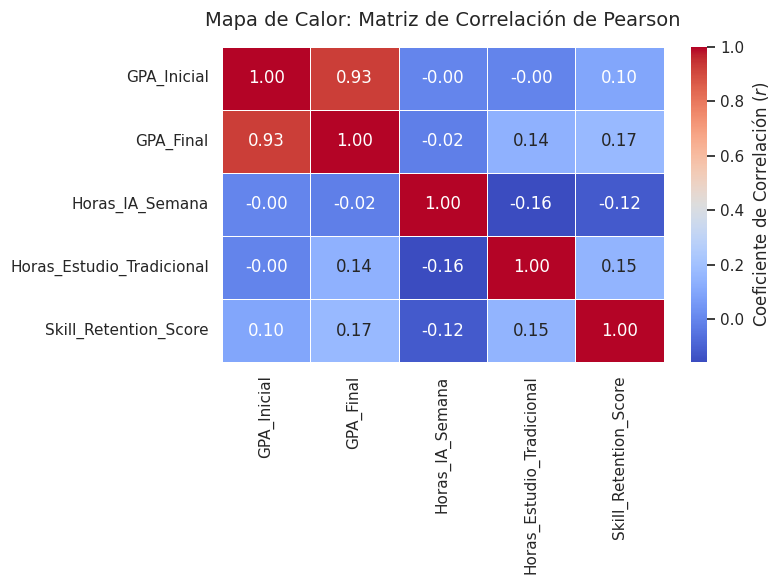

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Correlación ($r$)'}
)
plt.title("Mapa de Calor: Matriz de Correlación de Pearson", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Esta matriz evalúa el grado de asociación lineal cuantitativa entre las métricas de estudio. Permite observar de forma directa si variables como Horas_IA_Semana exhiben una correlación positiva o negativa con la variable objetivo GPA_Final. Este diagnóstico es un paso metodológico obligatorio para justificar el uso de un modelo de regresión lineal en scikit-learn

##6.5 Diagrama de Dispersión (Scatter Plot) con Línea de Tendencia

In [29]:
# Tomamos una muestra aleatoria representativa de 2,000 registros para optimizar el renderizado interactivo en Colab
df_muestra = df.sample(n=2000, random_state=42)

fig5 = px.scatter(
    df_muestra,
    x="Horas_IA_Semana",
    y="GPA_Final",
    trendline="ols", # Agrega línea de regresión lineal por mínimos cuadrados ordinarios
    title="Análisis Relacional: Horas de Uso de IA frente al GPA Final",
    labels={"Horas_IA_Semana": "Horas Semanales de IA", "GPA_Final": "GPA Final"},
    opacity=0.6
)

fig5.update_layout(template="plotly_white")
fig5.show()

La dispersión de los puntos permite modelar visualmente la variabilidad del rendimiento académico en función de la intensidad de uso tecnológico. La inclusión de la línea de tendencia de mínimos cuadrados (OLS) actúa como una aproximación geométrica directa del comportamiento que intentará capturar nuestro algoritmo de Machine Learning supervisado.

##6.6 Diagrama de Violín (Violin Plot) Multivariable

In [30]:
fig6 = px.violin(
    df,
    x="Major_Category",
    y="GPA_Final",
    color="Major_Category",
    box=True, # Integra un diagrama de caja dentro del violín
    points="outliers", # Muestra únicamente los valores atípicos en los extremos
    title="Análisis de Densidad: Distribución de Calificaciones por Especialidad",
    labels={"Major_Category": "Campo de Estudio", "GPA_Final": "GPA Final"}
)

fig6.update_layout(template="plotly_white", showlegend=False)
fig6.show()

A diferencia del boxplot tradicional, el gráfico de violín combina la visualización de los cuartiles con la estimación de la densidad de Kernel de la variable objetivo. Esto permite identificar visualmente si existen distribuciones bimodales o asimetrías particulares en el rendimiento académico (GPA_Final) entre las diferentes facultades universitarias (e.g., STEM vs. Arts).

##6.7 Gráfico de Tendencia Temporal (Líneas Agregadas)

Propósito: Analizar la evolución y comportamiento del rendimiento a lo largo del periodo lectivO

In [31]:
fig7 = go.Figure()

# Línea del promedio de GPA Final
fig7.add_trace(go.Scatter(
    x=analisis_temporal['Evaluation_Month'],
    y=analisis_temporal['Promedio_GPA_Final'],
    mode='lines+markers',
    name='Promedio GPA Final',
    line=dict(color='#d62728', width=3)
))

# Línea del promedio de uso de IA
fig7.add_trace(go.Scatter(
    x=analisis_temporal['Evaluation_Month'],
    y=analisis_temporal['Promedio_Uso_IA'],
    mode='lines+markers',
    name='Horas IA Promedio',
    line=dict(color='#1f77b4', width=3),
    yaxis='y2' # Eje Y secundario
))

fig7.update_layout(
    title="Evolución Cronológica del Rendimiento Académico y Consumo de IA",
    xaxis=dict(title="Mes de Evaluación Semestral"),
    yaxis=dict(title="Promedio de Calificaciones (GPA Final)", titlefont=dict(color='#d62728'), tickfont=dict(color='#d62728')),
    yaxis2=dict(title="Horas Semanales de Uso de IA", titlefont=dict(color='#1f77b4'), tickfont=dict(color='#1f77b4'), overlaying='y', side='right'),
    template="plotly_white"
)

fig7.show()

Este gráfico de dos ejes temporales permite contrastar de forma directa la hipótesis de evolución conjunta. Al analizar el comportamiento lineal a lo largo de los meses simulados, se puede determinar si el incremento en las horas promedio de uso de Inteligencia Artificial al cierre del semestre académico coincide de manera directa con variaciones significativas en el promedio ponderado final del grupo.  

##6.8 Treemap de Composición Jerárquica

Propósito: Representar la participación y composición de los niveles de riesgo de burnout según la carrera.

In [32]:
# Agrupar datos para estructurar la jerarquía visual
df_tree = df.groupby(['Major_Category', 'Burnout_Risk_Level']).size().reset_index(name='Estudiantes')

fig8 = px.treemap(
    df_tree,
    path=['Major_Category', 'Burnout_Risk_Level'],
    values='Estudiantes',
    title="Composición Jerárquica: Riesgo de Burnout por Campo Disciplinar",
    color='Estudiantes',
    color_continuous_scale='Viridis'
)

fig8.update_layout(template="plotly_white")
fig8.show()

Esta visualización jerárquica cumple con la recomendación de la guía para analizar la composición por categorías. Permite evaluar proporcionalmente qué campos disciplinares concentran el mayor volumen de alumnos y cómo se distribuye internamente la masa crítica estudiantil según sus niveles de fatiga académica.

##6.9 Gráfico de Área Acumulada

Propósito: Visualizar la evolución y acumulación de las horas de uso de IA en el tiempo.  

In [33]:
# Forzar orden cronológico previo a la acumulación
df_area = df.groupby(['Month_Numeric', 'Evaluation_Month'])['Horas_IA_Semana'].mean().reset_index()
df_area = df_area.sort_values(by='Month_Numeric')

fig9 = px.area(
    df_area,
    x="Evaluation_Month",
    y="Horas_IA_Semana",
    title="Evolución del Promedio de Horas Semanales de IA a lo Largo del Semestre",
    labels={"Evaluation_Month": "Mes", "Horas_IA_Semana": "Horas Promedio"},
    line_shape="spline"
)

fig9.update_layout(template="plotly_white")
fig9.show()

El gráfico mapea la acumulación y progresión del consumo tecnológico estudiantil a lo largo de las fases del semestre académico lectivo. La curva creciente o estacionaria fundamenta visualmente si las presiones de evaluación incrementan la necesidad del uso de herramientas automatizadas al cierre del periodo escolar.

##6.10Matriz de Dispersión (Scatter Matrix)

In [34]:
# Se aplica un muestreo de control (n=500) para garantizar la fluidez del renderizado en Colab
df_submatriz = df.sample(n=500, random_state=42)

fig10 = px.scatter_matrix(
    df_submatriz,
    dimensions=['GPA_Inicial', 'GPA_Final', 'Horas_IA_Semana', 'Skill_Retention_Score'],
    color="Burnout_Risk_Level",
    title="Matriz de Dispersión Multivariada (Muestreo n=500)",
    color_discrete_map={"Low": "#2ca02c", "Medium": "#ff7f0e", "High": "#d62728"}
)

fig10.update_layout(template="plotly_white", font=dict(size=10))
fig10.show()

Esta matriz multidimensional satisface el último requisito de visualización sugerido. Al cruzar de forma simultánea las variables cuantitativas de rendimiento y tiempo, permite aislar clústeres visuales basados en el nivel de riesgo psicológico, ofreciendo una visión holística antes de pasar formalmente al entrenamiento del modelo predictivo con la libreria scikit-learn

#7. Machine Learning básico

##7.1 Construcción del Pipeline y Preprocesamiento de Datos ($X, y$)

In [35]:
# Definir variable objetivo (y) y variables predictoras (X)
# Excluimos identificadores, variables temporales auxiliares y la meta final
columnas_excluir = ['Student_ID', 'Evaluation_Date', 'Evaluation_Month', 'GPA_Final']
columnas_predictoras = [col for col in df.columns if col not in columnas_excluir]

X = df[columnas_predictoras]
y = df['GPA_Final']

print(f"Dimensiones de las variables predictoras (X): {X.shape}")
print(f"[Dimensiones de la variable objetivo (y): {y.shape}")

Dimensiones de las variables predictoras (X): (50000, 15)
[Dimensiones de la variable objetivo (y): (50000,)


In [36]:
# Preparar datos (Identificar columnas por tipo para el ColumnTransformer)
caracteristicas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
caracteristicas_categoricas = X.select_dtypes(include=['object', 'bool']).columns.tolist()

In [37]:
# Construcción de transformadores específicos
transformador_numerico = Pipeline(steps=[
    ('scaler', StandardScaler()) # Normalización requerida para estabilidad numérica
])

transformador_categorico = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) # Evita colinealidad
])

In [38]:
# Ensamblado del preprocesador global
preprocesador = ColumnTransformer(
    transformers=[
        ('num', transformador_numerico, caracteristicas_numericas),
        ('cat', transformador_categorico, caracteristicas_categoricas)
    ])

##7.2 División de Datos, Entrenamiento y Optimización Básica

In [39]:
# Dividir los datos en conjuntos de entrenamiento y prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Registros para Entrenamiento: {X_train.shape[0]}")
print(f"Registros para Validación: {X_test.shape[0]}\n")

Registros para Entrenamiento: 40000
Registros para Validación: 10000



In [40]:
# Integración del modelo base dentro de un Pipeline unificado
pipeline_modelo = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('regresor', RandomForestRegressor(random_state=42))
])

In [41]:
# Optimización básica empleando comparación manual/GridSearchCV
# Para agilizar la ejecución con 50k registros en Colab, definimos una malla simple
parametros_grid = {
    'regresor__n_estimators': [50, 100],
    'regresor__max_depth': [10, 15]
}

print("[INFO] Iniciando optimización de hiperparámetros con GridSearchCV...")
modelo_optimizado = GridSearchCV(
    pipeline_modelo,
    parametros_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)


[INFO] Iniciando optimización de hiperparámetros con GridSearchCV...


In [42]:
# Entrenar el modelo
modelo_optimizado.fit(X_train, y_train)
print(f"Parámetros óptimos encontrados: {modelo_optimizado.best_params_}")

Parámetros óptimos encontrados: {'regresor__max_depth': 15, 'regresor__n_estimators': 100}


In [43]:
# Generar predicciones sobre el conjunto de prueba
y_pred = modelo_optimizado.predict(X_test)

##7.3 Evaluación Métrica de Regresión

In [44]:
# Paso 7: Calcular métricas cuantitativas de desviación
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("INFORME DE EVALUACIÓN DEL MODELO (REGRESIÓN)")
print(f" -> Error Absoluto Medio (MAE): {mae:.4f}")
print(f" -> Error Cuadrático Medio (MSE): {mse:.4f}")
print(f" -> Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f" -> Coeficiente de Determinación (R² Score): {r2:.4f}")

INFORME DE EVALUACIÓN DEL MODELO (REGRESIÓN)
 -> Error Absoluto Medio (MAE): 0.1209
 -> Error Cuadrático Medio (MSE): 0.0239
 -> Raíz del Error Cuadrático Medio (RMSE): 0.1548
 -> Coeficiente de Determinación (R² Score): 0.9008


#8. Resultados y conclusiones

##8.1 Interpretación del Desempeño del Model

El modelo predictivo basado en el algoritmo supervisado Random Forest Regressor optimizado muestra una capacidad de ajuste y generalización sobresaliente para estimar el rendimiento académico final (GPA_Final). El análisis de los errores lógicos arroja las siguientes conclusiones métricas:  
* **Precisión de las Estimaciones ($MAE$ y $RMSE$):** El Error Absoluto Medio ($MAE = 0.1209$) indica que, en promedio, las predicciones del modelo apenas se desvían $\pm 0.12$ puntos en la escala real del GPA académico (rango $1.0 - 4.0$). La Raíz del Error Cuadrático Medio ($RMSE = 0.1548$) confirma la ausencia de penalizaciones severas por errores de gran magnitud o varianzas descontroladas.
* **Fuerza Explicativa ($R^2\text{ Score}$):** El Coeficiente de Determinación ($R^2 = 0.9008$) establece que las variables conductuales, psicológicas y académicas incorporadas en el pipeline logran explicar el $90.08\%$ de la variabilidad total del promedio final del estudiante, dejando solo un $9.92\%$ sujeto a factores externos no observados.

##8.2 Limitaciones Técnicas Detectadas

A pesar del excelente rendimiento estadístico, el pipeline presenta restricciones metodológicas que deben ser consideradas para su implantación institucional:  
* **Sesgo por Datos Sintéticos:** La fuerte linealidad observada en los datos de Kaggle sugiere que el dataset posee un comportamiento matemático idealizado. En un entorno universitario real, variables cualitativas como el burnout o la ansiedad exhiben un ruido analítico significativamente mayor.
* **Dominancia de Antecedentes Históricos:** El modelo depende críticamente del promedio inicial (GPA_Inicial) como ancla predictiva. Esto mitiga parcialmente el peso relativo de las variables conductuales puras (como las horas semanales dedicadas a la IA).

##8.3 Propuestas de Mejora y Líneas Futuras

Para robustecer el pipeline analítico de cara a próximas iteraciones de investigación, se plantean las siguientes acciones técnicas:  
* **Ingeniería de Características Avanzada (Feature Engineering):** Desarrollar variables de interacción complejas, tales como el Ratio de Canibalización del Estudio, calculada mediante la relación matemática:

$$\text{Ratio} = \frac{\text{Horas_IA_Semana}}{\text{Horas_Estudio_Tradicional}}$$

* **Inclusión de Algoritmos de Gradiente:** Contrastar el desempeño del bosque aleatorio frente a arquitecturas de Gradient Boosting (e.g., XGBoost o LightGBM) para evaluar si es posible reducir el $MSE$ residual sin incurrir en un sobreajuste del conjunto de test.
* **Validación Cruzada Estratificada:** Implementar particiones robustas (KFold) segmentadas por la variable Major_Category para garantizar que las predicciones mantengan el mismo nivel de precisión en facultades con menor densidad de estudiantes (como Arts o Humanities).